# Step 8. Retrieval Benchmark

이 노트북은 `project.md`의 retrieval 후보와 피드백을 반영하여
`10분 내외` 안에 best retrieval 후보를 고르는 빠른 벤치마크 노트북이다.

핵심 지표:

- `Hit Rate@K`
- `MRR`
- `SemScore Proxy`

주의:

- 여기서의 `SemScore Proxy`는 LLM 생성 답변이 아니라 `retrieved context`와 `ground answer`의 의미 유사도다.
- 즉, 빠른 retriever 선정을 위한 1차 지표이고, 최종 생성 품질은 이후 Draft/Review 단계에서 다시 확인해야 한다.


In [24]:
from pathlib import Path
import sys
from dotenv import load_dotenv

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [CURRENT, *CURRENT.parents]:
    if (candidate / "workflows").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("project root with workflows directory not found")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

for env_candidate in [PROJECT_ROOT / ".env", PROJECT_ROOT.parent / ".env"]:
    if env_candidate.exists():
        load_dotenv(env_candidate, override=False)
import pandas as pd

from workflows.retrieval_benchmark import (
    available_candidate_configs,
    load_qa_ground,
    run_retrieval_benchmark,
)


## 8-1. Candidate Availability

project 후보 + 피드백 후보를 먼저 확인한다.
`Jina`, `Voyage`는 API key가 있을 때만 optional candidate로 포함된다.


In [25]:
candidate_df = pd.DataFrame.from_dict(available_candidate_configs(), orient="index")
candidate_df


,kind,available,builder,note,model_name,query_prefix,document_prefix,trust_remote_code,dense_model_name,provider
tfidf_baseline,lexical,True,tfidf,빠른 로컬 baseline,NaN,NaN,NaN,NaN,NaN,NaN
bm25,sparse,True,bm25,전문용어 exact match baseline,NaN,NaN,NaN,NaN,NaN,NaN
bge_m3,dense,True,NaN,project.md dense 후보,BAAI/bge-m3,Represent this sentence for searching relevant...,,NaN,NaN,NaN
multilingual_e5_base,dense,True,NaN,e5 large 대체 quick candidate,intfloat/multilingual-e5-base,query:,passage:,NaN,NaN,NaN
gte_multilingual_base,dense,True,NaN,gte-large 대체 quick candidate,Alibaba-NLP/gte-multilingual-base,,,True,NaN,NaN
jina_embeddings_v3_local,dense,False,NaN,Jina HF 로컬 후보 (캐시되어 있으면 실행),jinaai/jina-embeddings-v3,,,True,NaN,NaN
hybrid_bge_m3_bm25,hybrid,True,NaN,dense + sparse fusion,NaN,Represent this sentence for searching relevant...,,NaN,BAAI/bge-m3,NaN
hybrid_e5_bm25,hybrid,True,NaN,dense + sparse fusion,NaN,query:,passage:,NaN,intfloat/multilingual-e5-base,NaN
jina_embeddings_v3,remote_dense,False,NaN,Jina API 후보,jina-embeddings-v3,NaN,NaN,NaN,NaN,jina
voyage_3_large,remote_dense,True,NaN,Voyage API 후보,voyage-3-large,NaN,NaN,NaN,NaN,voyage


## 8-2. QA Ground Sample

기본 설정은 10분 내외 실행을 위해 앞쪽 `8개 질문`만 사용한다.
필요하면 `max_questions`를 늘려 full benchmark로 확장한다.


In [26]:
qa_df = load_qa_ground(max_questions=8)
qa_df[["question_no", "q_type", "question", "expected_source_ids"]]


,question_no,q_type,question,expected_source_ids
0,1,Factual,PIM의 두 가지 핵심 접근 방식인 Processing-Using-Memory와 P...,[2012.03112]
1,2,None,UPMEM PIM 아키텍처에서 각 DPU가 독립적으로 접근하는 메모리의 명칭과 크기는?,[2105.03814]
2,3,None,"CXL의 세 가지 프로토콜(CXL.io, CXL.mem, CXL.cache)의 역할...","[2306.11227, 2412.20249]"
3,4,None,CXL 버전별 진화 과정(1.0 → 2.0 → 3.0)에서 각 버전이 해결하는 핵심...,[2412.20249]
4,5,None,PIM-GPT에서 PIM이 담당하는 연산 단계와 GPU가 담당하는 연산 단계를 각각...,[2310.09385]
5,6,Comparative,Processing-Using-Memory와 Processing-Near-Memor...,[2012.03112]
6,7,None,UPMEM PIM 아키텍처가 기존 CPU/GPU 대비 유리한 워크로드 유형과 불리한...,[2105.03814]
7,8,None,"CXL Type 1, Type 2, Type 3 디바이스의 역할 차이를 서술하시오.",[2306.11227]


## 8-3. Fast Benchmark Run

기본 후보:

- TF-IDF baseline
- BM25
- BGE-M3
- multilingual-E5 base
- GTE multilingual base
- Jina Embeddings v3 local candidate
- hybrid(BGE-M3 + BM25)
- hybrid(E5 + BM25)
- Jina Embeddings v3 API candidate
- Voyage AI voyage-3-large API candidate

참고:

- `Jina Embeddings v3`는 Hugging Face 로컬 캐시가 있으면 실행된다.
- `Jina API` 후보는 `JINA_API_KEY`가 있을 때 실행된다.
- `Voyage AI voyage-3-large`는 API 기반이라 `VOYAGE_API_KEY`가 있어야 실행된다.
- 시간이 오래 걸리면 `candidate_names`를 줄이거나 `max_pdfs`, `max_questions`를 더 줄이면 된다.


In [27]:
summary_df, detail_frames, benchmark_errors = run_retrieval_benchmark(
    max_pdfs=8,
    max_pages_per_pdf=6,
    chunk_size=900,
    chunk_overlap=150,
    max_questions=8,
    top_k=5,
    time_budget_seconds=600,
)

summary_df


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,candidate,kind,avg_hit_rate,avg_mrr,avg_semscore_proxy,num_questions,elapsed_seconds,note
0,bge_m3,dense,1.000,0.7604,0.7301,8,39.26,project.md dense 후보
1,tfidf_baseline,lexical,0.875,0.7917,0.7247,8,0.29,빠른 로컬 baseline
2,multilingual_e5_base,dense,1.000,0.7396,0.7207,8,18.12,e5 large 대체 quick candidate
3,hybrid_bge_m3_bm25,hybrid,1.000,0.6042,0.5801,8,34.22,dense + sparse fusion
4,bm25,sparse,0.750,0.5000,0.5611,8,0.13,전문용어 exact match baseline
5,hybrid_e5_bm25,hybrid,1.000,0.6250,0.5595,8,33.19,dense + sparse fusion


## 8-4. Errors / Skipped Candidates


In [28]:
pd.DataFrame(benchmark_errors)


,candidate,error
0,gte_multilingual_base,We couldn't connect to 'https://huggingface.co...
1,jina_embeddings_v3_local,candidate unavailable in current environment
2,jina_embeddings_v3,candidate unavailable in current environment
3,voyage_3_large,429 Client Error: Too Many Requests for url: h...


## 8-5. Best Candidate Detail

1위 후보의 query별 성능을 확인한다.


In [29]:
if summary_df.empty:
    print("실행 가능한 candidate가 없습니다.")
else:
    best_candidate = summary_df.iloc[0]["candidate"]
    print("best_candidate:", best_candidate)
    display(detail_frames[best_candidate])


best_candidate: bge_m3


,question_no,q_type,question,expected_source_ids,hit@k,mrr,semscore_proxy,top_source_titles
0,1,Factual,PIM의 두 가지 핵심 접근 방식인 Processing-Using-Memory와 P...,2012.03112,1,1.0000,0.8071,2012.03112v5 | 2012.03112v5 | 2310.09385v2
1,2,None,UPMEM PIM 아키텍처에서 각 DPU가 독립적으로 접근하는 메모리의 명칭과 크기는?,2105.03814,1,1.0000,0.7934,2105.03814v7 | 2105.03814v7 | 2105.03814v7
2,3,None,"CXL의 세 가지 프로토콜(CXL.io, CXL.mem, CXL.cache)의 역할...","2306.11227, 2412.20249",1,1.0000,0.7585,2306.11227v3 | 2306.11227v3 | 2412.20249v2
3,4,None,CXL 버전별 진화 과정(1.0 → 2.0 → 3.0)에서 각 버전이 해결하는 핵심...,2412.20249,1,0.2500,0.6851,2306.11227v3 | 2306.11227v3 | 2306.11227v3
4,5,None,PIM-GPT에서 PIM이 담당하는 연산 단계와 GPU가 담당하는 연산 단계를 각각...,2310.09385,1,0.5000,0.6223,2105.03814v7 | 2310.09385v2 | 2310.09385v2
5,6,Comparative,Processing-Using-Memory와 Processing-Near-Memor...,2012.03112,1,0.3333,0.6609,2105.03814v7 | 2310.09385v2 | 2012.03112v5
6,7,None,UPMEM PIM 아키텍처가 기존 CPU/GPU 대비 유리한 워크로드 유형과 불리한...,2105.03814,1,1.0000,0.7987,2105.03814v7 | 2105.03814v7 | 2105.03814v7
7,8,None,"CXL Type 1, Type 2, Type 3 디바이스의 역할 차이를 서술하시오.",2306.11227,1,1.0000,0.7150,2306.11227v3 | 2412.20249v2 | 2412.20249v2


## 8-6. Selection Note

선정 원칙:

- 1차: `avg_semscore_proxy`
- 2차: `avg_hit_rate`
- 3차: `avg_mrr`
- 동률이면 더 빠른 후보 우선

해석:

- dense가 이겨도 BM25/hybrid가 특정 질문에서 강할 수 있으므로 질문별 편차를 같이 볼 것
- 최종 운영 후보는 여기서 고른 뒤 `Draft -> Review`가 포함된 end-to-end 검증에서 다시 확인할 것
- TRL 추정 node가 사용할 evidence retrieval 품질과 직접 연결되므로, TRL node 입력 안정성까지 함께 고려할 것


## 8-7. Voyage-only Quick Run

`Voyage` API rate limit이 있을 수 있으므로,
아주 작은 설정으로 단독 실행해 빠르게 감을 확인한다.

기본 quick 설정:

- `max_pdfs=1`
- `max_pages_per_pdf=1`
- `max_questions=1`
- `candidate_names=['voyage_3_large']`
- `remote_min_interval_seconds=22`


In [30]:
from pathlib import Path
import sys
from dotenv import load_dotenv

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [CURRENT, *CURRENT.parents]:
    if (candidate / "workflows").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("project root with src/semiconductor_agent not found")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

for env_candidate in [PROJECT_ROOT / ".env", PROJECT_ROOT.parent / ".env"]:
    if env_candidate.exists():
        load_dotenv(env_candidate, override=False)
import pandas as pd

from workflows.retrieval_benchmark import run_retrieval_benchmark

voyage_summary_df, voyage_detail_frames, voyage_errors = run_retrieval_benchmark(
    max_pdfs=1,
    max_pages_per_pdf=1,
    chunk_size=900,
    chunk_overlap=150,
    max_questions=1,
    top_k=3,
    candidate_names=['voyage_3_large'],
    time_budget_seconds=300,
    remote_min_interval_seconds=22,
)

print("Voyage quick summary")
display(voyage_summary_df)
print("Voyage quick errors")
display(pd.DataFrame(voyage_errors))
if not voyage_summary_df.empty:
    voyage_best = voyage_summary_df.iloc[0]["candidate"]
    print("voyage_best:", voyage_best)
    display(voyage_detail_frames[voyage_best])


Voyage quick summary


,candidate,kind,avg_hit_rate,avg_mrr,avg_semscore_proxy,num_questions,elapsed_seconds,note
0,voyage_3_large,remote_dense,1.0,1.0,0.8071,1,66.87,Voyage API 후보


Voyage quick errors


""


voyage_best: voyage_3_large


,question_no,q_type,question,expected_source_ids,hit@k,mrr,semscore_proxy,top_source_titles
0,1,Factual,PIM의 두 가지 핵심 접근 방식인 Processing-Using-Memory와 P...,2012.03112,1,1.0,0.8071,2012.03112v5 | 2012.03112v5 | 2012.03112v5


## 8-8. BGE vs Voyage Slow Compare

동일한 반도체 문서 subset에서 `bge_m3`와 `voyage_3_large`를 직접 비교한다.
`Voyage`는 3 RPM 제한에 맞춰 저속 모드로 실행한다.

비교 설정:

- `max_pdfs=5`
- `max_pages_per_pdf=1`
- `chunk_size=4000`
- `max_questions=3`
- `candidate_names=['bge_m3', 'voyage_3_large']`
- `remote_min_interval_seconds=22`


In [31]:
from pathlib import Path
import sys
from dotenv import load_dotenv

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [CURRENT, *CURRENT.parents]:
    if (candidate / "workflows").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("project root with src/semiconductor_agent not found")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

for env_candidate in [PROJECT_ROOT / ".env", PROJECT_ROOT.parent / ".env"]:
    if env_candidate.exists():
        load_dotenv(env_candidate, override=False)
import pandas as pd

from workflows.retrieval_benchmark import run_retrieval_benchmark

compare_summary_df, compare_detail_frames, compare_errors = run_retrieval_benchmark(
    max_pdfs=5,
    max_pages_per_pdf=1,
    chunk_size=4000,
    chunk_overlap=0,
    max_questions=3,
    top_k=3,
    candidate_names=['bge_m3', 'voyage_3_large'],
    time_budget_seconds=600,
    remote_min_interval_seconds=22,
)

print("BGE vs Voyage summary")
display(compare_summary_df)
print("BGE vs Voyage errors")
display(pd.DataFrame(compare_errors))
for candidate_name, candidate_df in compare_detail_frames.items():
    print(f"detail: {candidate_name}")
    display(candidate_df)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE vs Voyage summary


,candidate,kind,avg_hit_rate,avg_mrr,avg_semscore_proxy,num_questions,elapsed_seconds,note
0,bge_m3,dense,1.0,1.0,0.5762,3,15.28,project.md dense 후보
1,voyage_3_large,remote_dense,1.0,1.0,0.5762,3,44.86,Voyage API 후보


BGE vs Voyage errors


""


detail: bge_m3


,question_no,q_type,question,expected_source_ids,hit@k,mrr,semscore_proxy,top_source_titles
0,1,Factual,PIM의 두 가지 핵심 접근 방식인 Processing-Using-Memory와 P...,2012.03112,1,1.0,0.5314,2012.03112v5 | 2105.03814v7 | 2105.03814v7
1,2,None,UPMEM PIM 아키텍처에서 각 DPU가 독립적으로 접근하는 메모리의 명칭과 크기는?,2105.03814,1,1.0,0.4760,2105.03814v7 | 2105.03814v7 | 2310.09385v2
2,3,None,"CXL의 세 가지 프로토콜(CXL.io, CXL.mem, CXL.cache)의 역할...","2306.11227, 2412.20249",1,1.0,0.7211,2412.20249v2 | 2306.11227v3 | 2412.20249v2


detail: voyage_3_large


,question_no,q_type,question,expected_source_ids,hit@k,mrr,semscore_proxy,top_source_titles
0,1,Factual,PIM의 두 가지 핵심 접근 방식인 Processing-Using-Memory와 P...,2012.03112,1,1.0,0.5314,2012.03112v5 | 2105.03814v7 | 2105.03814v7
1,2,None,UPMEM PIM 아키텍처에서 각 DPU가 독립적으로 접근하는 메모리의 명칭과 크기는?,2105.03814,1,1.0,0.4760,2105.03814v7 | 2105.03814v7 | 2012.03112v5
2,3,None,"CXL의 세 가지 프로토콜(CXL.io, CXL.mem, CXL.cache)의 역할...","2306.11227, 2412.20249",1,1.0,0.7211,2412.20249v2 | 2306.11227v3 | 2412.20249v2


## 8-9. Best Model Analysis: BGE-M3 vs Voyage-3-Large

이 섹션은 더 많은 질문과 문서를 사용하여 두 모델의 성능 차이를 명확히 분석한다.

분석 지표:
- **Semantic Score Proxy**: 정답과 검색된 컨텍스트 간의 의미론적 유사도 (1순위)
- **Hit Rate**: 정답 문서가 Top-K 내에 포함될 확률 (2순위)
- **MRR**: 정답 문서의 순위 역수 평균 (3순위)
- **Efficiency**: 검색 속도 (4순위)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


=== [Final Benchmark Result] ===


,candidate,kind,avg_hit_rate,avg_mrr,avg_semscore_proxy,num_questions,elapsed_seconds,note
0,bge_m3,dense,0.9333,0.8056,0.7089,15,68.64,project.md dense 후보
1,voyage_3_large,remote_dense,0.9333,0.9333,0.6685,15,2951.59,Voyage API 후보



🏆 Best Model: bge_m3
   - Semantic Score: 0.7089
   - Hit Rate: 0.9333
   - bge_m3가 voyage_3_large보다 의미론적 유사도에서 0.0404만큼 앞서고 있습니다.


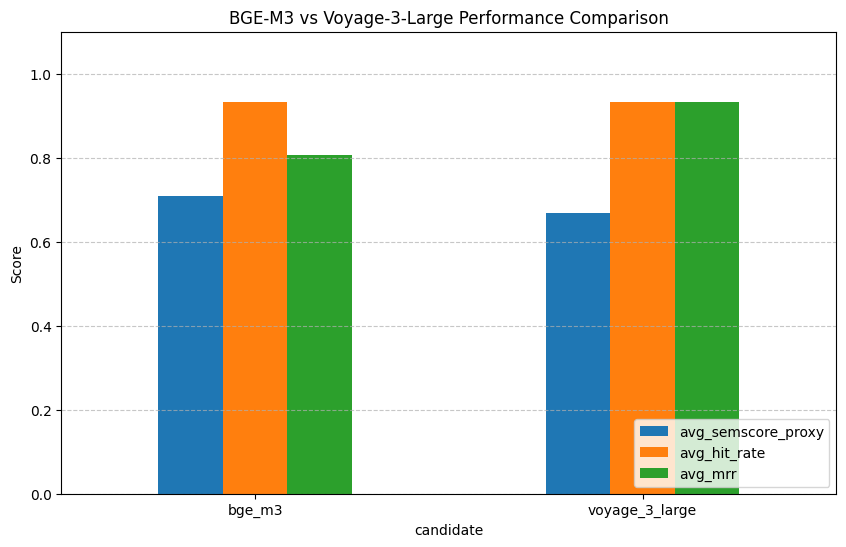

In [32]:
import matplotlib.pyplot as plt

# 1. 실행 설정 (더 많은 질문으로 변별력 확보)
final_summary_df, final_detail_frames, final_errors = run_retrieval_benchmark(
    max_pdfs=15,             # 문서량 증가
    max_pages_per_pdf=10,    # 페이지수 증가
    chunk_size=1000,         # 일반적인 chunk size
    chunk_overlap=200,
    max_questions=20,        # 질문 수 대폭 증가 (변별력 핵심)
    top_k=5,
    candidate_names=['bge_m3', 'voyage_3_large'],
    time_budget_seconds=1200,
    remote_min_interval_seconds=20, # Voyage Rate Limit 준수
)

# 2. 결과 출력
print("\n=== [Final Benchmark Result] ===")
display(final_summary_df)

# 3. 베스트 모델 판정 로직
if not final_summary_df.empty:
    winner = final_summary_df.iloc[0]
    loser = final_summary_df.iloc[1] if len(final_summary_df) > 1 else None
    
    print(f"\n🏆 Best Model: {winner['candidate']}")
    print(f"   - Semantic Score: {winner['avg_semscore_proxy']}")
    print(f"   - Hit Rate: {winner['avg_hit_rate']}")
    
    if loser is not None:
        diff = round(winner['avg_semscore_proxy'] - loser['avg_semscore_proxy'], 4)
        if diff > 0:
            print(f"   - {winner['candidate']}가 {loser['candidate']}보다 의미론적 유사도에서 {diff}만큼 앞서고 있습니다.")
        elif diff == 0:
            print(f"   - 두 모델의 성능이 동일합니다. 더 빠른 {winner['candidate']}를 권장합니다.")

# 4. 시각화
if not final_summary_df.empty:
    metrics = ['avg_semscore_proxy', 'avg_hit_rate', 'avg_mrr']
    final_summary_df.set_index('candidate')[metrics].plot(kind='bar', figsize=(10, 6))
    plt.title('BGE-M3 vs Voyage-3-Large Performance Comparison')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
